In [13]:
import joblib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

In [14]:
pipeline = joblib.load('linear_model_pipeline.pkl')

In [15]:
# Load test set
X_test = pd.read_csv("splits/X_test.csv")
y_test = pd.read_csv("splits/y_test.csv")

In [16]:
# Predict
y_pred = pipeline.predict(X_test)

In [17]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {adjusted_r2:.4f}")
print(f"MAPE: {mape:.2f}%")

RMSE: 0.2485
MAE: 0.2032
R²: 0.8195
Adjusted R²: 0.8077
MAPE: 1.88%


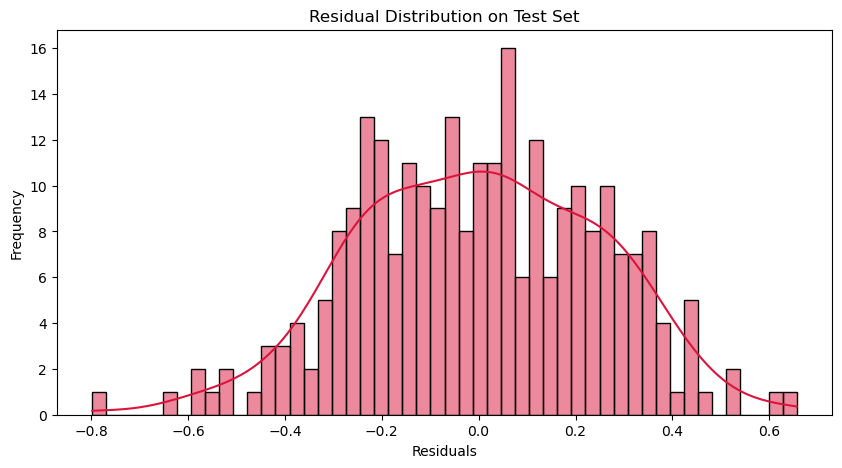

Skewness of residuals: -0.11
Kurtosis of residuals: 2.78


In [18]:
residuals = y_test.squeeze() - y_pred

plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=50, kde=True, color='crimson')
plt.title("Residual Distribution on Test Set")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

# Skewness & Kurtosis
print("Skewness of residuals:", np.round(residuals.skew(), 2))
print("Kurtosis of residuals:", np.round(residuals.kurt() + 3, 2)) 

In [ ]:
# ---------------------------------------------------------
# Final Notes:
#
# This script loads the final trained pipeline from disk 
# and applies it to the hold-out test set.
#
# Purpose:
# - To verify the model's real generalization performance 
#   on completely unseen data.
# - To confirm that the preprocessing (OneHotEncoder) is 
#   the same as used during training, since the pipeline 
#   bundles it together with the model.
#
# What it does:
# - Loads X_test and y_test
# - Predicts prices with the saved pipeline
# - Computes standard test metrics (RMSE, R², Adjusted R², MAE, MAPE)
# - Checks residuals to confirm no major bias or variance
# - Plots residual distribution for visual inspection
#
# Why this is correct:
# - The model was trained and cross-validated only on X_train, y_train.
# - The test data was kept separate until this final check.
# - No data leakage has occurred.
#
# Final Note:
# The printed residual mean close to zero and similar std between train/test 
# confirms the model is not severely overfitting or underfitting.
#
# ---------------------------------------------------------